In [2]:
import geopandas as gpd
print("geopandas imported successfully.")

geopandas imported successfully.


In [3]:
delhi_ncr_gdf = gpd.read_file('/content/delhi_ncr_region.geojson')
print(f"Delhi-NCR GeoDataFrame loaded successfully with {len(delhi_ncr_gdf)} features.")
delhi_ncr_gdf.head()

Delhi-NCR GeoDataFrame loaded successfully with 30 features.


,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."


In [4]:
delhi_ncr_proj = delhi_ncr_gdf.to_crs(epsg=32643)
print(f"Reprojected GeoDataFrame CRS: {delhi_ncr_proj.crs}")
delhi_ncr_proj.head()

Reprojected GeoDataFrame CRS: EPSG:32643


,geometry
0,"POLYGON ((681647.35 3123088.65, 681757.14 3123..."
1,"POLYGON ((709716.57 3242533.024, 709810.153 32..."
2,"MULTIPOLYGON (((705455 3018827, 705708.5 30187..."
3,"POLYGON ((790220.498 3179588.253, 790236.508 3..."
4,"POLYGON ((716145.844 3186203.817, 716234.798 3..."


In [5]:
from shapely.geometry import Polygon

#bounds of reprojected Delhi-NCR region
minx, miny, maxx, maxy = delhi_ncr_proj.total_bounds

grid_size_meters = 60000

# min and max coordinates for the grid
x_coords = [minx + i * grid_size_meters for i in range(int((maxx - minx) / grid_size_meters) + 2)]
y_coords = [miny + i * grid_size_meters for i in range(int((maxy - miny) / grid_size_meters) + 2)]

grid_polygons = []
for i in range(len(x_coords) - 1):
    for j in range(len(y_coords) - 1):
        poly = Polygon([
            (x_coords[i], y_coords[j]),
            (x_coords[i+1], y_coords[j]),
            (x_coords[i+1], y_coords[j+1]),
            (x_coords[i], y_coords[j+1]),
            (x_coords[i], y_coords[j])
        ])
        grid_polygons.append(poly)

grid_gdf = gpd.GeoDataFrame(geometry=grid_polygons, crs=delhi_ncr_proj.crs)

print(f"Generated a grid with {len(grid_gdf)} cells.")
grid_gdf.head()

Generated a grid with 35 cells.


,geometry
0,"POLYGON ((546143 2956097.26, 606143 2956097.26..."
1,"POLYGON ((546143 3016097.26, 606143 3016097.26..."
2,"POLYGON ((546143 3076097.26, 606143 3076097.26..."
3,"POLYGON ((546143 3136097.26, 606143 3136097.26..."
4,"POLYGON ((546143 3196097.26, 606143 3196097.26..."


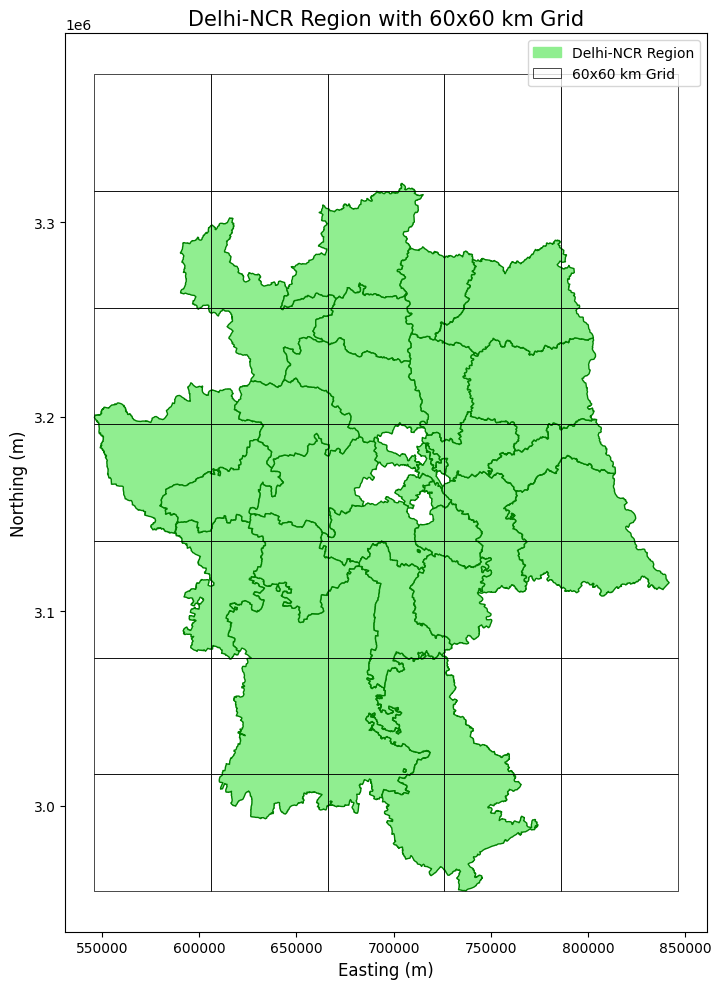

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create a plot with two subplots or layers
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the Delhi-NCR shapefile
delhi_ncr_proj.plot(ax=ax, color='lightgreen', edgecolor='green', label='Delhi-NCR Region')

# Overlay the generated grid
grid_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, label='60x60 km Grid')

# Set title and labels
ax.set_title('Delhi-NCR Region with 60x60 km Grid', fontsize=15)
ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)

# Create custom legend handles
delhi_ncr_patch = mpatches.Patch(color='lightgreen', label='Delhi-NCR Region')
grid_patch = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=0.5, label='60x60 km Grid')

# Add a legend using the custom handles
ax.legend(handles=[delhi_ncr_patch, grid_patch])

# Display the plot
plt.tight_layout()
plt.show()

## Simulating Satellite Image Coordinates



In [9]:
import numpy as np
import pandas as pd


In [11]:
import random

min_lon, min_lat, max_lon, max_lat = delhi_ncr_gdf.total_bounds

ext_factor = 0.1
expanded_min_lon = min_lon - ext_factor
expanded_min_lat = min_lat - ext_factor
expanded_max_lon = max_lon + ext_factor
expanded_max_lat = max_lat + ext_factor

num_images = 1000

simulated_longitudes = [random.uniform(expanded_min_lon, expanded_max_lon) for _ in range(num_images)]
simulated_latitudes = [random.uniform(expanded_min_lat, expanded_max_lat) for _ in range(num_images)]

image_coords_df = pd.DataFrame({
    'longitude': simulated_longitudes,
    'latitude': simulated_latitudes
})

print(f"Generated {len(image_coords_df)} simulated satellite image coordinates.")
image_coords_df.head()

Generated 1000 simulated satellite image coordinates.


,longitude,latitude
0,78.273623,27.629735
1,77.101917,29.340369
2,75.778021,29.454866
3,75.998295,29.076554
4,77.633918,27.519589


## Filtering Satellite Images by Delhi-NCR Region



In [12]:
import geopandas as gpd

image_coords_gdf = gpd.GeoDataFrame(
    image_coords_df,
    geometry=gpd.points_from_xy(image_coords_df.longitude, image_coords_df.latitude),
    crs="EPSG:4326"
)

print(f"Created image_coords_gdf with {len(image_coords_gdf)} points and CRS: {image_coords_gdf.crs}")
image_coords_gdf.head()

Created image_coords_gdf with 1000 points and CRS: EPSG:4326


,longitude,latitude,geometry
0,78.273623,27.629735,POINT (78.27362 27.62974)
1,77.101917,29.340369,POINT (77.10192 29.34037)
2,75.778021,29.454866,POINT (75.77802 29.45487)
3,75.998295,29.076554,POINT (75.9983 29.07655)
4,77.633918,27.519589,POINT (77.63392 27.51959)


In [13]:
image_coords_gdf = image_coords_gdf.to_crs(delhi_ncr_proj.crs)
print(f"Reprojected image_coords_gdf CRS: {image_coords_gdf.crs}")
image_coords_gdf.head()

Reprojected image_coords_gdf CRS: EPSG:32643


,longitude,latitude,geometry
0,78.273623,27.629735,POINT (823065.214 3060470.511)
1,77.101917,29.340369,POINT (704076.29 3247531.3)
2,75.778021,29.454866,POINT (575446.212 3258634.449)
3,75.998295,29.076554,POINT (597164.759 3216878.551)
4,77.633918,27.519589,POINT (760165.813 3046750.997)


In [14]:
images_in_delhi_ncr_gdf = gpd.sjoin(image_coords_gdf, delhi_ncr_proj, predicate='intersects', how='inner')

print(f"Number of simulated satellite images within Delhi-NCR region: {len(images_in_delhi_ncr_gdf)}")
images_in_delhi_ncr_gdf.head()

Number of simulated satellite images within Delhi-NCR region: 432


,longitude,latitude,geometry,index_right
1,77.101917,29.340369,POINT (704076.29 3247531.3),25
5,76.693906,27.808132,POINT (666856.956 3077099.377),0
6,77.365606,28.030270,POINT (732564.466 3102812.565),24
8,76.961920,29.140801,POINT (690851.087 3225176.899),28
9,77.674364,28.305110,POINT (762258.625 3133905.24),5


In [15]:
print(f"Total simulated satellite images before filtering: {len(image_coords_df)}")
print(f"Simulated satellite images within Delhi-NCR region after filtering: {len(images_in_delhi_ncr_gdf)}")

Total simulated satellite images before filtering: 1000
Simulated satellite images within Delhi-NCR region after filtering: 432


In [16]:
import rasterio

In [17]:
land_cover_dataset = rasterio.open('/content/worldcover_bbox_delhi_ncr_2021.tif')

print(f"CRS: {land_cover_dataset.crs}")
print(f"Transform: {land_cover_dataset.transform}")
print(f"Width: {land_cover_dataset.width}")
print(f"Height: {land_cover_dataset.height}")

CRS: EPSG:4326
Transform: | 0.00, 0.00, 76.85|
| 0.00,-0.00, 29.00|
| 0.00, 0.00, 1.00|
Width: 9602
Height: 9600


In [19]:
import rasterio.windows

land_cover_patches = []
patch_size = 128

raster_width = land_cover_dataset.width
raster_height = land_cover_dataset.height

for idx, row in images_in_delhi_ncr_gdf.iterrows():
    point = row.geometry

    longitude = row['longitude']
    latitude = row['latitude']

    col, row_pixel = land_cover_dataset.index(longitude, latitude)

    half_patch = patch_size // 2

    left = max(0, col - half_patch)
    top = max(0, row_pixel - half_patch)
    right = min(raster_width, col + half_patch)
    bottom = min(raster_height, row_pixel + half_patch)

    if (right - left) < patch_size:
        if left == 0: # If at left edge, expand right
            right = min(raster_width, left + patch_size)
        elif right == raster_width: # If at right edge, expand left
            left = max(0, right - patch_size)

    if (bottom - top) < patch_size:
        if top == 0: # If at top edge, expand bottom
            bottom = min(raster_height, top + patch_size)
        elif bottom == raster_height: # If at bottom edge, expand top
            top = max(0, bottom - patch_size)

    window_width = right - left
    window_height = bottom - top

    if window_width > 0 and window_height > 0:
        window = rasterio.windows.Window(left, top, window_width, window_height)

        try:
            patch = land_cover_dataset.read(1, window=window)
            if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
                padded_patch = np.zeros((patch_size, patch_size), dtype=patch.dtype)
                padded_patch[:patch.shape[0], :patch.shape[1]] = patch
                land_cover_patches.append(padded_patch)
            else:
                land_cover_patches.append(patch)
        except Exception as e:
            print(f"Could not read window for image at ({longitude}, {latitude}): {e}")

print(f"Extracted {len(land_cover_patches)} land cover patches of size {patch_size}x{patch_size}.")


Extracted 432 land cover patches of size 128x128.


In [20]:
import numpy as np

dominant_land_cover_labels = []

for patch in land_cover_patches:
    unique_values, counts = np.unique(patch, return_counts=True)

    if len(counts) > 0:
        dominant_class = unique_values[np.argmax(counts)]
        dominant_land_cover_labels.append(dominant_class)
    else:
        dominant_land_cover_labels.append(np.nan)

print(f"Determined dominant land cover labels for {len(dominant_land_cover_labels)} patches.")
print("First 10 dominant land cover labels:", dominant_land_cover_labels[:10])

Determined dominant land cover labels for 432 patches.
First 10 dominant land cover labels: [np.uint8(40), np.uint8(50), np.uint8(50), np.uint8(40), np.uint8(40), np.uint8(40), np.uint8(50), np.uint8(40), np.uint8(40), np.uint8(40)]


In [21]:
esa_to_simplified_mapping = {
    10: 'Vegetation',   # Tree cover
    20: 'Vegetation',   # Shrubland
    30: 'Vegetation',   # Grassland
    40: 'Cropland',     # Cropland
    50: 'Built-up',     # Built-up
    60: 'Others',       # Bare/sparse vegetation
    70: 'Others',       # Snow and ice
    80: 'Water',        # Permanent water bodies
    90: 'Vegetation',   # Herbaceous wetland (often vegetation-dominated)
    95: 'Vegetation',   # Mangroves (a type of tree cover)
    100: 'Others'      # Moss and lichen
}

simplified_land_cover_labels = []
for label in dominant_land_cover_labels:
    simplified_label = esa_to_simplified_mapping.get(int(label), 'Others')
    simplified_land_cover_labels.append(simplified_label)

print(f"Created {len(simplified_land_cover_labels)} simplified land cover labels.")
print("First 10 simplified land cover labels:", simplified_land_cover_labels[:10])

Created 432 simplified land cover labels.
First 10 simplified land cover labels: ['Cropland', 'Built-up', 'Built-up', 'Cropland', 'Cropland', 'Cropland', 'Built-up', 'Cropland', 'Cropland', 'Cropland']


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(land_cover_patches, simplified_land_cover_labels, test_size=0.4, random_state=42)

print(f"Number of samples in X_train: {len(X_train)}")
print(f"Number of samples in X_test: {len(X_test)}")
print(f"Number of samples in y_train: {len(y_train)}")
print(f"Number of samples in y_test: {len(y_test)}")

Number of samples in X_train: 259
Number of samples in X_test: 173
Number of samples in y_train: 259
Number of samples in y_test: 173


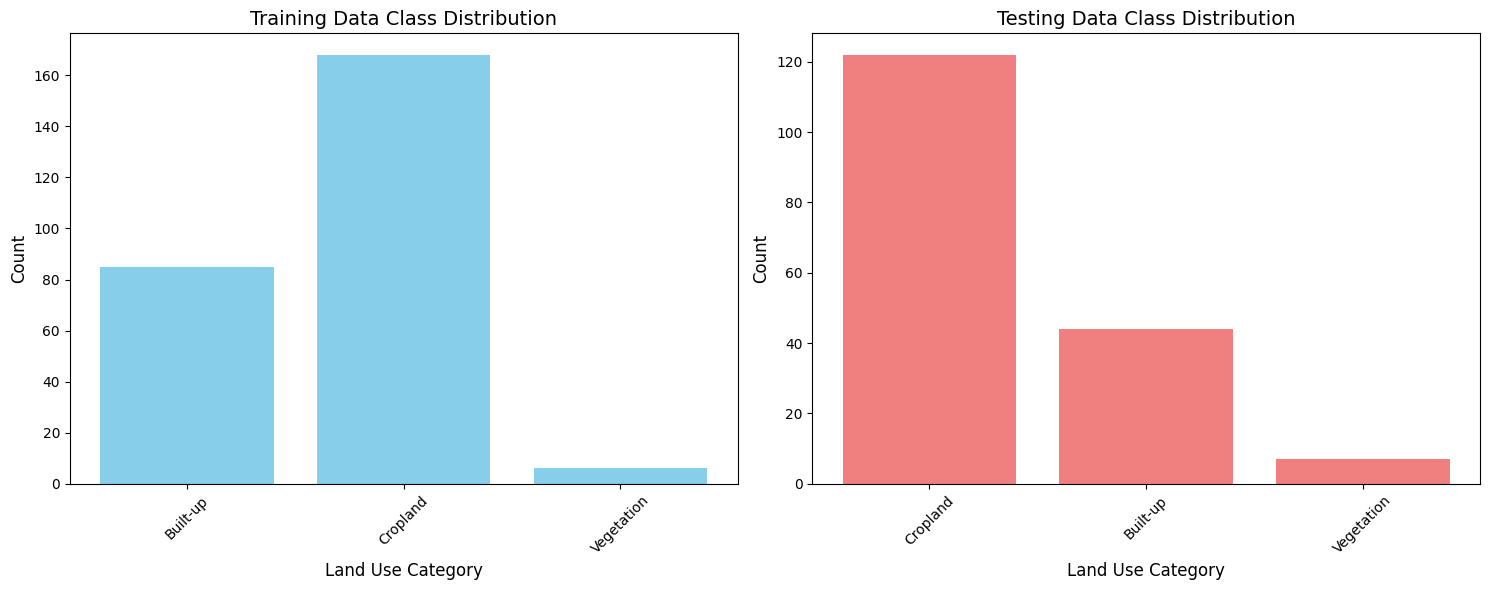

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

train_counts = Counter(y_train)
train_categories = list(train_counts.keys())
train_values = list(train_counts.values())
ax[0].bar(train_categories, train_values, color='skyblue')
ax[0].set_title('Training Data Class Distribution', fontsize=14)
ax[0].set_xlabel('Land Use Category', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)

test_counts = Counter(y_test)
test_categories = list(test_counts.keys())
test_values = list(test_counts.values())
ax[1].bar(test_categories, test_values, color='lightcoral')
ax[1].set_title('Testing Data Class Distribution', fontsize=14)
ax[1].set_xlabel('Land Use Category', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## CNN Training


In [26]:
from sklearn.preprocessing import LabelEncoder
import torch


In [27]:
label_encoder = LabelEncoder()

all_labels = list(set(y_train) | set(y_test))
label_encoder.fit(all_labels)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

y_train_tensor = torch.LongTensor(y_train_encoded)
y_test_tensor = torch.LongTensor(y_test_encoded)

print(f"Original y_train sample: {y_train[:5]}")
print(f"Encoded y_train_tensor sample: {y_train_tensor[:5]}")
print(f"Original y_test sample: {y_test[:5]}")
print(f"Encoded y_test_tensor sample: {y_test_tensor[:5]}")
print(f"Unique classes encoded: {label_encoder.classes_}")

Original y_train sample: ['Built-up', 'Built-up', 'Built-up', 'Cropland', 'Built-up']
Encoded y_train_tensor sample: tensor([0, 0, 0, 1, 0])
Original y_test sample: ['Cropland', 'Cropland', 'Built-up', 'Built-up', 'Built-up']
Encoded y_test_tensor sample: tensor([1, 1, 0, 0, 0])
Unique classes encoded: ['Built-up' 'Cropland' 'Vegetation']


In [28]:
import numpy as np

X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

X_train_tensor = torch.FloatTensor(X_train_np)
X_test_tensor = torch.FloatTensor(X_test_np)

X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

X_train_tensor = X_train_tensor / 100.0
X_test_tensor = X_test_tensor / 100.0

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"X_train_tensor data type: {X_train_tensor.dtype}")
print(f"X_train_tensor min value: {X_train_tensor.min()}, max value: {X_train_tensor.max()}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"X_test_tensor data type: {X_test_tensor.dtype}")
print(f"X_test_tensor min value: {X_test_tensor.min()}, max value: {X_test_tensor.max()}")

X_train_tensor shape: torch.Size([259, 1, 128, 128])
X_train_tensor data type: torch.float32
X_train_tensor min value: 0.0, max value: 0.8999999761581421
X_test_tensor shape: torch.Size([173, 1, 128, 128])
X_test_tensor data type: torch.float32
X_test_tensor min value: 0.0, max value: 0.8999999761581421


In [29]:
import torch.nn as nn
import torch.nn.functional as F


In [30]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1) # Input: 1 channel (grayscale), Output: 16 channels
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # Input: 16 channels, Output: 32 channels

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
num_classes = len(label_encoder.classes_)
model = SimpleCNN(num_classes=num_classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [31]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64
num_epochs = 10
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training parameters set:\n  Batch Size: {batch_size}\n  Number of Epochs: {num_epochs}\n  Learning Rate: {learning_rate}\nLoss Function: {criterion.__class__.__name__}\nOptimizer: {optimizer.__class__.__name__}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Training parameters set:
  Batch Size: 64
  Number of Epochs: 10
  Learning Rate: 0.001
Loss Function: CrossEntropyLoss
Optimizer: Adam
Number of batches in train_loader: 5
Number of batches in test_loader: 3


## Train the CNN Model



In [32]:
train_losses = []
train_accuracies = []

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

print("Finished Training.")

Starting training...
Epoch 1/10, Loss: 1.0189, Accuracy: 63.71%
Epoch 2/10, Loss: 0.5337, Accuracy: 81.85%
Epoch 3/10, Loss: 0.3554, Accuracy: 87.64%
Epoch 4/10, Loss: 0.2583, Accuracy: 88.80%
Epoch 5/10, Loss: 0.1270, Accuracy: 94.59%
Epoch 6/10, Loss: 0.0840, Accuracy: 98.07%
Epoch 7/10, Loss: 0.0776, Accuracy: 95.75%
Epoch 8/10, Loss: 0.0352, Accuracy: 99.23%
Epoch 9/10, Loss: 0.0215, Accuracy: 100.00%
Epoch 10/10, Loss: 0.0185, Accuracy: 99.23%
Finished Training.


In [33]:
from sklearn.metrics import accuracy_score, f1_score

In [34]:
model.eval()

all_labels = []
all_predicted = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

overall_accuracy = accuracy_score(all_labels, all_predicted)

f1_macro = f1_score(all_labels, all_predicted, average='macro')

f1_weighted = f1_score(all_labels, all_predicted, average='weighted')

print(f"Overall Accuracy on Test Set: {overall_accuracy:.4f}")
print(f"F1-Score (Macro Average) on Test Set: {f1_macro:.4f}")
print(f"F1-Score (Weighted Average) on Test Set: {f1_weighted:.4f}")

Overall Accuracy on Test Set: 0.9249
F1-Score (Macro Average) on Test Set: 0.7043
F1-Score (Weighted Average) on Test Set: 0.9120


In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


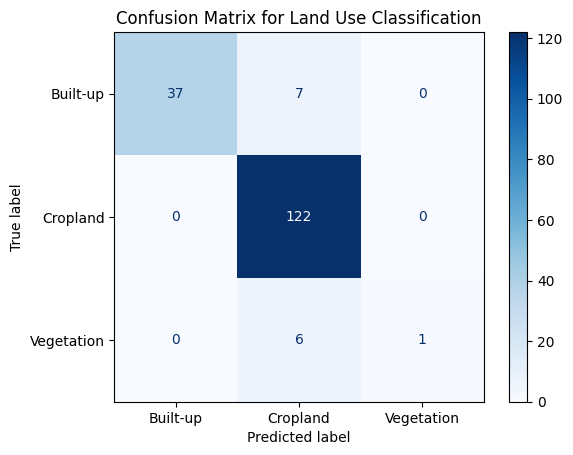

In [36]:
cm = confusion_matrix(all_labels, all_predicted)

class_names = label_encoder.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Land Use Classification')
plt.show()